# The Student Data Journey — Part 2
## Transforming, Reducing, and Modelling Student Data
### *The Maplewood High School Analytics Project — Continued*

---

> **Story so far:** In Part 1, we explored our 500-student dataset, handled missing data,
> removed outliers, and learned how to sample and summarise.
>
> **Now the real transformation begins.** Machine learning algorithms are mathematical —
> they can only work with numbers in specific ranges and formats.
> In this notebook, we convert, scale, reshape, and ultimately **model** our data.
>
> By the end, we'll have a working model that predicts a student's final grade
> from features we can measure at the start of semester.

---

## Key Vocabulary

| Term | Simple Explanation |
|------|-------------------|
| **Normalisation** | Rescaling numbers so they all live on the same scale |
| **Min-Max Scaling** | Squish all values into the range [0, 1] |
| **Z-Score** | Measure how many "standard deviations" a value is from the mean |
| **Box-Cox** | A mathematical trick to make skewed data look more bell-shaped |
| **Encoding** | Turning category labels (like 'Male') into numbers |
| **Discretization** | Grouping continuous numbers into labelled bins (A, B, C, D, F) |
| **Concept Hierarchy** | Replacing specific values with broader categories (e.g., grade → pass/fail) |
| **Clustering** | Grouping similar items together — without being told what the groups are |
| **Similarity** | A measure of how alike two students (or data points) are |
| **PCA** | Principal Component Analysis — a way to compress many features into fewer |
| **Linear Regression** | A model that draws the best straight line through the data to predict values |
| **R² Score** | How well our model explains the variation in grades (1.0 = perfect) |

## What You'll Learn in Part 2

1. **Why normalisation matters** — and when to use Min-Max vs Z-Score vs Box-Cox
2. How to **encode categorical variables** into numbers (Label Encoding & One-Hot Encoding)
3. How to **discretize** continuous grades into letter grades
4. What **concept hierarchies** are and how to build one
5. How **K-Means clustering** finds natural student groups
6. What **similarity measures** are used in clustering
7. How **PCA** compresses 5 features into 2 dimensions for visualisation
8. How **data reduction by sampling** differs from Part 1 sampling
9. How to build and evaluate a **Linear Regression** model
10. How to connect everything back to supervised vs. unsupervised learning

---

In [1]:
# ──────────────────────────────────────────────────────────────────
# SETUP — Import all libraries + Rebuild the clean dataset
# We rebuild the dataset from scratch so Part 2 is self-contained.
# ──────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Rebuild the same dataset from Part 1 ─────────────────────────
N = 500
study_hours     = np.random.normal(5.0, 2.0, N).clip(0, 12)
attendance_pct  = np.random.normal(80,  15,   N).clip(0, 100)
socio_score     = np.random.normal(5.5, 2.0, N).clip(1, 10)
prev_gpa        = np.random.normal(2.8, 0.7, N).clip(0, 4)
gender          = np.random.choice(['Male', 'Female'], N)
parent_education= np.random.choice(
    ['No HS', 'High School', 'Some College', "Bachelor's", 'Graduate'],
    N, p=[0.08, 0.27, 0.25, 0.28, 0.12]
)
extracurricular = np.random.choice(['Yes', 'No'], N, p=[0.38, 0.62])
noise           = np.random.normal(0, 7, N)
final_grade     = (
    study_hours * 4.5 + attendance_pct * 0.25 +
    socio_score * 1.5 + prev_gpa * 5.0 + noise + 5
).clip(0, 100)

df = pd.DataFrame({
    'student_id'      : [f'S{i:04d}' for i in range(1, N + 1)],
    'study_hours'     : study_hours.round(1),
    'attendance_pct'  : attendance_pct.round(1),
    'socio_score'     : socio_score.round(1),
    'prev_gpa'        : prev_gpa.round(2),
    'gender'          : gender,
    'parent_education': parent_education,
    'extracurricular' : extracurricular,
    'final_grade'     : final_grade.round(1),
})

print(f'Dataset ready: {df.shape[0]} students x {df.shape[1]} attributes')
print(f'Numeric columns: {list(df.select_dtypes(include=np.number).columns)}')

Dataset ready: 500 students x 9 attributes
Numeric columns: ['study_hours', 'attendance_pct', 'socio_score', 'prev_gpa', 'final_grade']


---
## Part 1: Data Transformation by Attribute Normalisation

### Why Do We Need to Normalise?

Imagine comparing someone's height in centimetres (165 cm) to their GPA (3.2).
A machine learning algorithm sees those as just numbers — and concludes height is
**50× more important** than GPA, simply because 165 is bigger than 3.2!

This is wrong. We need to **rescale** all features to a common range so that scale
doesn't artificially control importance.

We'll compare three normalisation techniques on the same data:

| Technique | Formula | Best For |
|-----------|---------|----------|
| **Min-Max** | `(x − min) / (max − min)` | When you need values in [0, 1] |
| **Z-Score** | `(x − mean) / std` | When data is roughly bell-shaped |
| **Box-Cox** | Complex power transform | When data is skewed and needs reshaping |

In [2]:
# ──────────────────────────────────────────────────────────────────
# MIN-MAX NORMALISATION
# Squishes every value into the range [0, 1].
# 0 = the minimum value in the column, 1 = the maximum.
# Formula: x_scaled = (x - x_min) / (x_max - x_min)
# ──────────────────────────────────────────────────────────────────

numeric_cols = ['study_hours', 'attendance_pct', 'socio_score', 'prev_gpa']

# ── Manual implementation (to show the math) ──────────────────────
df_minmax = df[numeric_cols].copy()
for col in numeric_cols:
    col_min = df_minmax[col].min()
    col_max = df_minmax[col].max()
    df_minmax[col] = (df_minmax[col] - col_min) / (col_max - col_min)

# ── sklearn version (what you'd use in production) ────────────────
scaler_minmax = MinMaxScaler()
df_minmax_sk  = pd.DataFrame(
    scaler_minmax.fit_transform(df[numeric_cols]),
    columns=[c + '_mm' for c in numeric_cols]
)

print('=== Min-Max Normalisation Results ===')
print('Before normalisation (original ranges):')
print(df[numeric_cols].agg(['min','max']).round(2).to_string())
print('\nAfter Min-Max normalisation (all values in [0, 1]):')
print(df_minmax.agg(['min','max']).round(4).to_string())
print('\nFirst 5 rows after normalisation:')
print(df_minmax.head().round(4).to_string())

=== Min-Max Normalisation Results ===
Before normalisation (original ranges):
     study_hours  attendance_pct  socio_score  prev_gpa
min        0.000          39.500        1.000     0.740
max       12.000         100.000       10.000     4.000

After Min-Max normalisation (all values in [0, 1]):
     study_hours  attendance_pct  socio_score  prev_gpa
min        0.000           0.000        0.000     0.000
max        1.000           1.000        1.000     1.000

First 5 rows after normalisation:
   study_hours  attendance_pct  socio_score  prev_gpa
0        0.500           0.899        0.811     0.797
1        0.392           1.000        0.700     0.512
2        0.525           0.322        0.511     0.457
3        0.667           0.808        0.356     0.632
4        0.375           0.507        0.656     0.595


In [3]:
# ──────────────────────────────────────────────────────────────────
# Z-SCORE NORMALISATION (STANDARDISATION)
# Centers data at 0 and scales by standard deviation.
# Result: mean=0, std=1. Negative values = below average.
# Formula: z = (x - mean) / std_deviation
# ──────────────────────────────────────────────────────────────────

df_zscore = df[numeric_cols].copy()
for col in numeric_cols:
    mean = df_zscore[col].mean()
    std  = df_zscore[col].std()
    df_zscore[col] = (df_zscore[col] - mean) / std

print('=== Z-Score Normalisation Results ===')
print('After Z-Score standardisation (mean≈0, std≈1):')
print(df_zscore.agg(['mean','std']).round(4).to_string())

# ── Interpret a specific value ────────────────────────────────────
example_study = df['study_hours'].iloc[0]
z_example     = (example_study - df['study_hours'].mean()) / df['study_hours'].std()
print(f'\nExample: Student 1 studies {example_study} hrs/week')
print(f'  Population mean: {df["study_hours"].mean():.2f} hrs')
print(f'  Z-Score: {z_example:.3f}')
if z_example > 0:
    print(f'  This student studies {abs(z_example):.2f} standard deviations ABOVE average')
else:
    print(f'  This student studies {abs(z_example):.2f} standard deviations BELOW average')

=== Z-Score Normalisation Results ===
After Z-Score standardisation (mean≈0, std≈1):
      study_hours  attendance_pct  socio_score  prev_gpa
mean        0.000          -0.000       -0.000     0.000
std         1.000           1.000        1.000     1.000

Example: Student 1 studies 6.0 hrs/week
  Population mean: 5.02 hrs
  Z-Score: 0.506
  This student studies 0.51 standard deviations ABOVE average


Box-Cox lambda found: 0.1495
(Lambda near 0 ≈ log transform; Lambda=1 ≈ no change; Lambda=0.5 ≈ square root)

Original  — Skewness: +1.8155
Box-Cox   — Skewness: -0.0302
(Skewness near 0 = symmetric / bell-shaped. We reduced it significantly!)


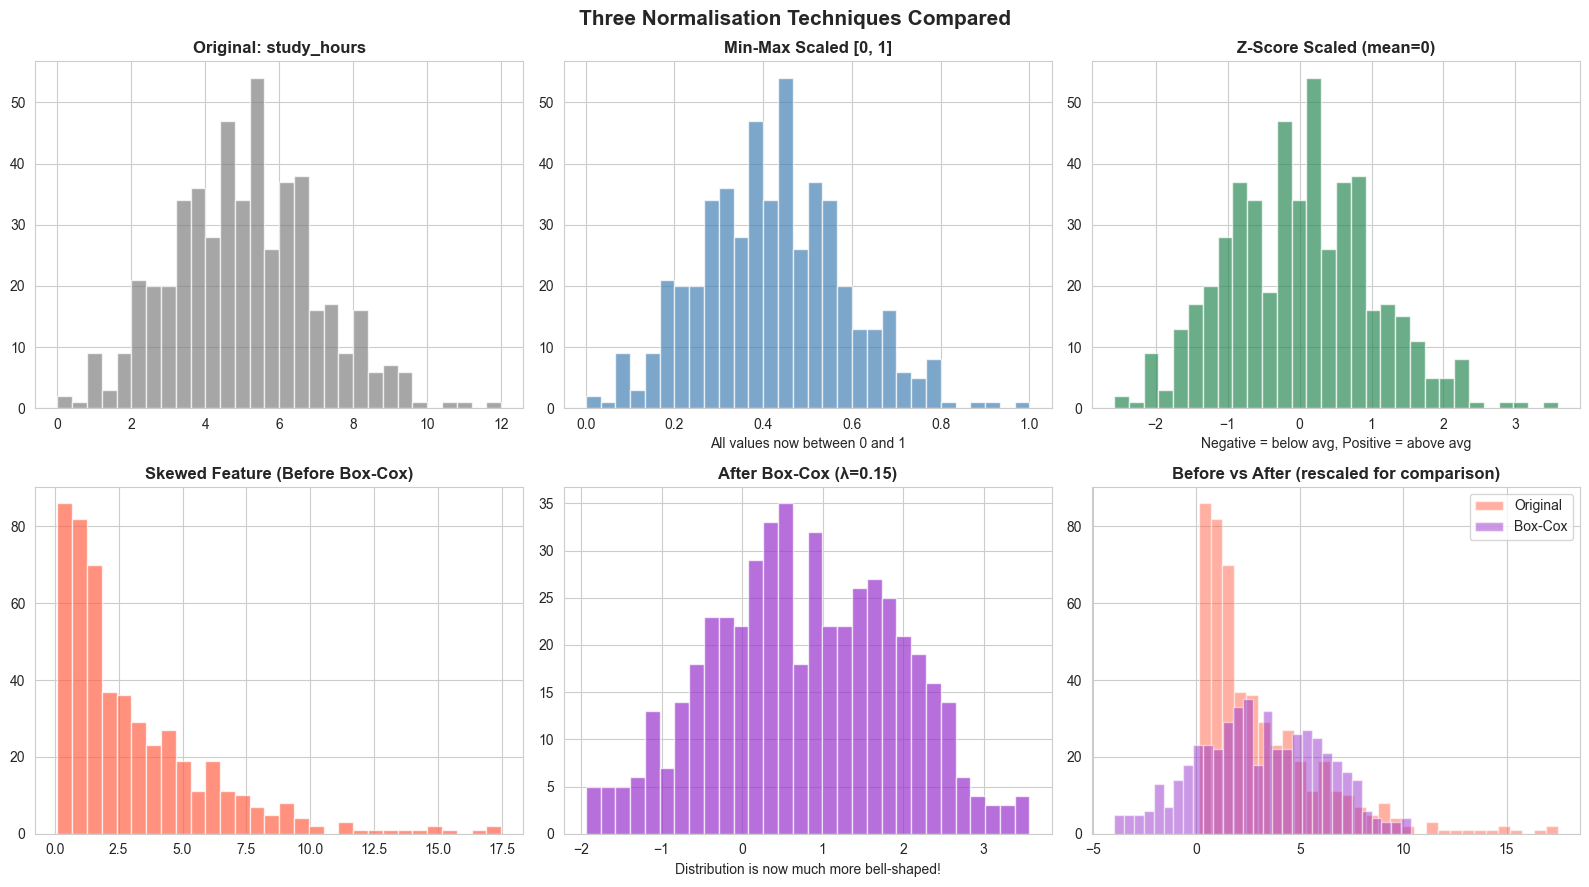

In [4]:
# ──────────────────────────────────────────────────────────────────
# BOX-COX TRANSFORMATION
# Some data is skewed — like income, house prices, or in our case,
# socioeconomic score if it were heavily right-skewed.
# Box-Cox finds the best power (lambda) to make the data bell-shaped.
# NOTE: Box-Cox requires all values > 0.
# ──────────────────────────────────────────────────────────────────

# Create a skewed version of socio_score to demonstrate Box-Cox clearly
# Real-world scenario: household income is typically right-skewed
skewed_feature = np.random.exponential(scale=3, size=N) + 0.1  # heavily right-skewed
skewed_feature = skewed_feature.clip(0.1, None)                 # ensure all > 0 for Box-Cox

# Apply Box-Cox transformation
boxcox_transformed, lambda_val = stats.boxcox(skewed_feature)

print(f'Box-Cox lambda found: {lambda_val:.4f}')
print(f'(Lambda near 0 ≈ log transform; Lambda=1 ≈ no change; Lambda=0.5 ≈ square root)')
print(f'\nOriginal  — Skewness: {stats.skew(skewed_feature):+.4f}')
print(f'Box-Cox   — Skewness: {stats.skew(boxcox_transformed):+.4f}')
print(f'(Skewness near 0 = symmetric / bell-shaped. We reduced it significantly!)')

# ── Visualise all three normalisation techniques side by side ─────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

raw_col = df['study_hours']

# Row 1: study_hours before and after Min-Max and Z-Score
axes[0, 0].hist(raw_col, bins=30, color='grey',      alpha=0.7, edgecolor='white')
axes[0, 0].set_title('Original: study_hours',           fontweight='bold')

axes[0, 1].hist(df_minmax['study_hours'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Min-Max Scaled [0, 1]',           fontweight='bold')
axes[0, 1].set_xlabel('All values now between 0 and 1')

axes[0, 2].hist(df_zscore['study_hours'], bins=30, color='seagreen',  alpha=0.7, edgecolor='white')
axes[0, 2].set_title('Z-Score Scaled (mean=0)',         fontweight='bold')
axes[0, 2].set_xlabel('Negative = below avg, Positive = above avg')

# Row 2: Box-Cox demo on skewed data
axes[1, 0].hist(skewed_feature,      bins=30, color='tomato',     alpha=0.7, edgecolor='white')
axes[1, 0].set_title('Skewed Feature (Before Box-Cox)',  fontweight='bold')

axes[1, 1].hist(boxcox_transformed, bins=30, color='darkorchid', alpha=0.7, edgecolor='white')
axes[1, 1].set_title(f'After Box-Cox (λ={lambda_val:.2f})',  fontweight='bold')
axes[1, 1].set_xlabel('Distribution is now much more bell-shaped!')

# Comparison overlay
axes[1, 2].hist(skewed_feature,      bins=30, alpha=0.5, color='tomato',     label='Original',  edgecolor='white')
axes[1, 2].hist((boxcox_transformed - boxcox_transformed.mean()) / boxcox_transformed.std() * skewed_feature.std() + skewed_feature.mean(),
                bins=30, alpha=0.5, color='darkorchid', label='Box-Cox', edgecolor='white')
axes[1, 2].set_title('Before vs After (rescaled for comparison)', fontweight='bold')
axes[1, 2].legend()

plt.suptitle('Three Normalisation Techniques Compared', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insight — Choose normalisation based on your data's shape:**

- **Min-Max**: Use when you need a strict [0, 1] range and your data has no extreme outliers.
  Good for neural networks. Sensitive to outliers (one huge value compresses everything else).
- **Z-Score**: Use when your data is roughly bell-shaped. The most common choice for ML.
  Negative values are fine — they just mean "below average."
- **Box-Cox**: Use when your data is skewed (income, prices, reaction times).
  Mathematically finds the best transformation to make it bell-shaped.

---

## Part 2: Data Transformation by Encoding

Machine learning models speak only one language: **numbers**.
But our dataset has text columns like `'Male'`, `'Female'`, `'High School'`, `'Graduate'`.

We need to **encode** these into numbers. Two main strategies:

---

### Label Encoding
Assign each category a number: `No HS=0`, `High School=1`, `Some College=2`, etc.
**Problem:** The model might think Graduate (4) is "twice as good" as Some College (2).
This is only valid if the categories have a true order (Ordinal data).

### One-Hot Encoding
Create a **new binary column** for each category. Each column is 1 if the student
belongs to that category, 0 otherwise.
No false ordering — each category is truly independent.
Use this for **nominal** categories (like gender, extracurricular).

In [5]:
# ──────────────────────────────────────────────────────────────────
# DATA TRANSFORMATION BY ENCODING
# We transform all categorical columns into numbers.
# ──────────────────────────────────────────────────────────────────

df_encoded = df.drop(columns=['student_id']).copy()

# ── Label Encoding: parent_education (it HAS a natural order) ─────
# No HS < High School < Some College < Bachelor's < Graduate
# So label encoding is appropriate here!
edu_order_map = {
    'No HS'        : 0,
    'High School'  : 1,
    'Some College' : 2,
    "Bachelor's"   : 3,
    'Graduate'     : 4,
}
df_encoded['parent_education_encoded'] = df_encoded['parent_education'].map(edu_order_map)
print('Label Encoding — parent_education:')
for label, code in edu_order_map.items():
    print(f'  "{label}" → {code}')

# ── One-Hot Encoding: gender and extracurricular ──────────────────
# These have NO natural order, so we create separate binary columns.
# pd.get_dummies() automatically creates one column per unique value.
ohe_gender = pd.get_dummies(df_encoded['gender'], prefix='gender', drop_first=True, dtype=int)
ohe_extra  = pd.get_dummies(df_encoded['extracurricular'], prefix='extra', drop_first=True, dtype=int)

# Combine everything into one ML-ready DataFrame
df_ml = pd.concat([
    df_encoded.drop(columns=['gender', 'extracurricular', 'parent_education']),
    ohe_gender,
    ohe_extra,
], axis=1)

print('\nOne-Hot Encoding — gender:')
print(ohe_gender.head(5).to_string())
print('\nOne-Hot Encoding — extracurricular:')
print(ohe_extra.head(5).to_string())

print(f'\nFinal ML-ready shape: {df_ml.shape}')
print(f'Columns: {list(df_ml.columns)}')

Label Encoding — parent_education:
  "No HS" → 0
  "High School" → 1
  "Some College" → 2
  "Bachelor's" → 3
  "Graduate" → 4

One-Hot Encoding — gender:
   gender_Male
0            0
1            1
2            0
3            1
4            1

One-Hot Encoding — extracurricular:
   extra_Yes
0          1
1          0
2          0
3          0
4          0

Final ML-ready shape: (500, 8)
Columns: ['study_hours', 'attendance_pct', 'socio_score', 'prev_gpa', 'final_grade', 'parent_education_encoded', 'gender_Male', 'extra_Yes']


---
## Part 3: Data Transformation by Discretization

Sometimes a continuous number carries more meaning as a **category**.
A final grade of `73.4%` is more intuitively understood as a **C** (or "average").

**Discretization** converts continuous values into buckets (bins).
This can make patterns more interpretable and sometimes improves certain models.

Methods:
- **Equal-Width Binning**: Each bin covers the same range (e.g., 0-20, 20-40, ...)
- **Equal-Frequency Binning**: Each bin has the same number of students
- **Custom Binning**: Use domain knowledge to define meaningful cut-points
  (like the real school grading system: A=90+, B=80-89, C=70-79, D=60-69, F=<60)

=== Discretization Results ===

Equal-Width Bins distribution:
grade_equal_width
Very Low      20
Low           93
Medium       200
High         147
Very High     40

Equal-Frequency (Quartile) Bins distribution:
grade_equal_freq
Q1 (Bottom 25%)    125
Q2                 126
Q3                 124
Q4 (Top 25%)       125

Custom Letter Grade distribution:
letter_grade
F    103
D    150
C    142
B     81
A     24


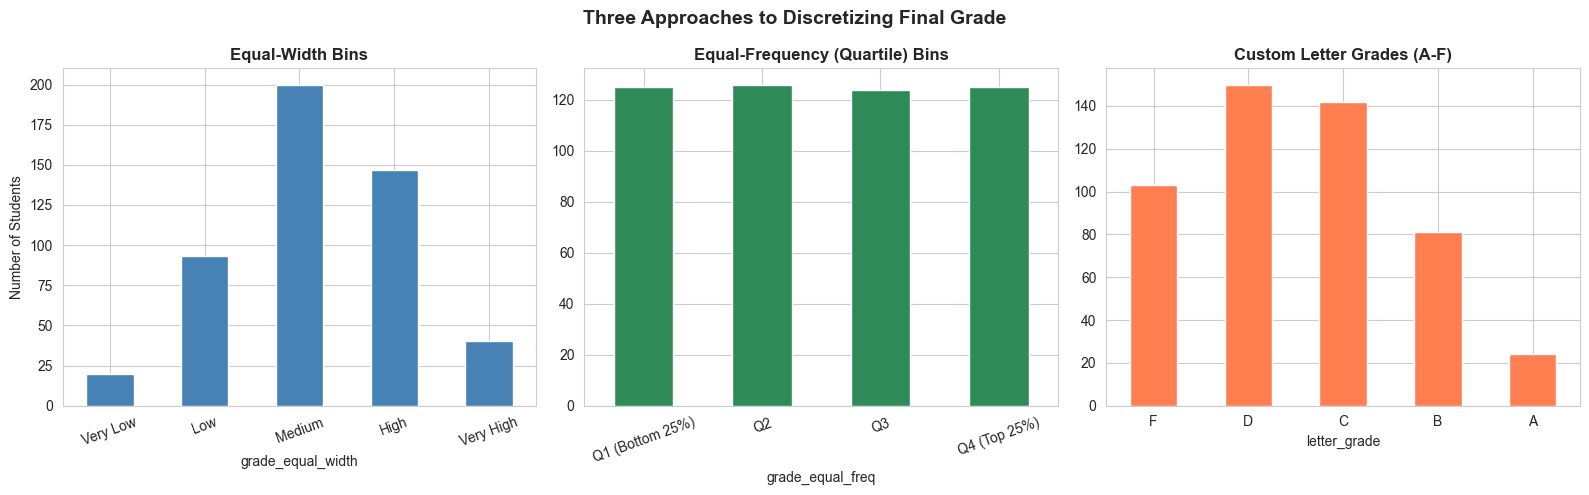

In [6]:
# ──────────────────────────────────────────────────────────────────
# DATA TRANSFORMATION BY DISCRETIZATION
# We convert final_grade (continuous) into grade bands.
# ──────────────────────────────────────────────────────────────────

# ── Method 1: Equal-Width Bins (5 equal ranges across 0–100) ──────
df['grade_equal_width'] = pd.cut(
    df['final_grade'],
    bins=5,               # split range into 5 equal-width chunks
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# ── Method 2: Equal-Frequency Bins (each bin has ~same count) ─────
df['grade_equal_freq'] = pd.qcut(
    df['final_grade'],
    q=4,                  # quartile-based — 25% per bin
    labels=['Q1 (Bottom 25%)', 'Q2', 'Q3', 'Q4 (Top 25%)']
)

# ── Method 3: Custom Bins (real school grading scale) ─────────────
grade_bins   = [0,  60,  70,  80,  90, 100]
grade_labels = ['F', 'D', 'C', 'B', 'A']
df['letter_grade'] = pd.cut(
    df['final_grade'],
    bins=grade_bins,
    labels=grade_labels,
    include_lowest=True
)

print('=== Discretization Results ===')
print('\nEqual-Width Bins distribution:')
print(df['grade_equal_width'].value_counts().sort_index().to_string())

print('\nEqual-Frequency (Quartile) Bins distribution:')
print(df['grade_equal_freq'].value_counts().sort_index().to_string())

print('\nCustom Letter Grade distribution:')
print(df['letter_grade'].value_counts().sort_index().to_string())

# ── Visualise all three ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['grade_equal_width'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Equal-Width Bins', fontweight='bold')
axes[0].set_ylabel('Number of Students')
axes[0].tick_params(axis='x', rotation=20)

df['grade_equal_freq'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Equal-Frequency (Quartile) Bins', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

df['letter_grade'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Custom Letter Grades (A-F)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Three Approaches to Discretizing Final Grade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 4: Data Transformation by Concept Hierarchies

A **concept hierarchy** replaces specific (fine-grained) values with broader (general) concepts.
This is a form of data generalisation — you zoom out from the details.

Think of it like going from:
- `73.4%` → `C` → `Pass` → `Completed`
- `Graduate` → `University-Educated` → `Higher Education`
- Monday → Weekday → School Day

Each level up loses some detail but reveals **higher-level patterns** that are easier to act on.

=== Concept Hierarchy: Final Grade ===
 final_grade letter_grade pass_fail   achievement
      86.400            B      Pass High Achiever
      65.700            D      Pass Needs Support
      70.000            D      Pass Needs Support
      82.500            B      Pass High Achiever
      53.300            F      Fail Needs Support
      59.400            F      Fail Needs Support
      84.000            B      Pass High Achiever
      91.900            A      Pass High Achiever
      73.100            C      Pass      On Track
      65.700            D      Pass Needs Support

=== Concept Hierarchy: Parent Education ===
parent_education      edu_level
      Bachelor's     University
        Graduate     University
     High School      Secondary
           No HS  Pre-Secondary
    Some College Post-Secondary


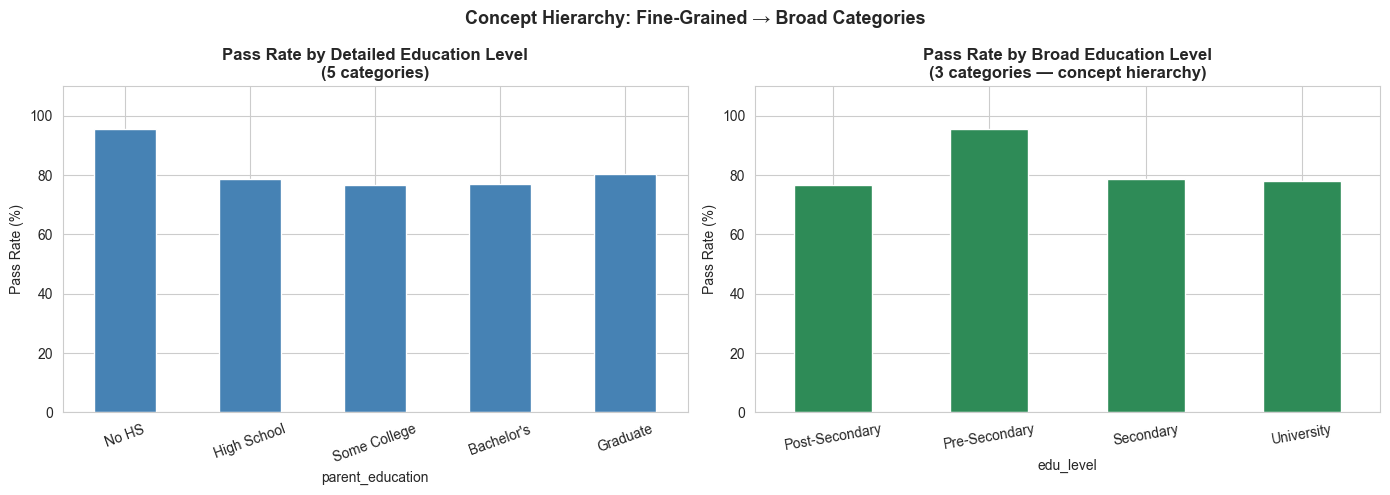

Pass Rate overall: 79.4%


In [7]:
# ──────────────────────────────────────────────────────────────────
# DATA TRANSFORMATION BY CONCEPT HIERARCHIES
# We build TWO hierarchies: one for grades, one for parent education.
# ──────────────────────────────────────────────────────────────────

# ── Hierarchy 1: Grade → Letter → Pass/Fail → Outcome ─────────────
def grade_to_pass_fail(grade):
    """Convert a percentage grade to Pass/Fail (threshold: 60%)."""
    return 'Pass' if grade >= 60 else 'Fail'

def letter_to_achievement(letter):
    """Map letter grade to a 3-level achievement category."""
    if letter in ['A', 'B']:
        return 'High Achiever'
    elif letter == 'C':
        return 'On Track'
    else:
        return 'Needs Support'

df['pass_fail']      = df['final_grade'].apply(grade_to_pass_fail)
df['achievement']    = df['letter_grade'].apply(letter_to_achievement)

# ── Hierarchy 2: parent_education → broad category ────────────────
edu_hierarchy = {
    'No HS'        : 'Pre-Secondary',
    'High School'  : 'Secondary',
    'Some College' : 'Post-Secondary',
    "Bachelor's"   : 'University',
    'Graduate'     : 'University',
}
df['edu_level'] = df['parent_education'].map(edu_hierarchy)

print('=== Concept Hierarchy: Final Grade ===')
hierarchy_demo = df[['final_grade','letter_grade','pass_fail','achievement']].head(10)
print(hierarchy_demo.to_string(index=False))

print('\n=== Concept Hierarchy: Parent Education ===')
edu_demo = df[['parent_education','edu_level']].drop_duplicates().sort_values('parent_education')
print(edu_demo.to_string(index=False))

# ── Visualise the hierarchy effect on pass/fail by edu level ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pass_rate_detail = df.groupby('parent_education')['pass_fail'].apply(
    lambda x: (x == 'Pass').mean() * 100).reindex(
    ['No HS', 'High School', 'Some College', "Bachelor's", 'Graduate'])

pass_rate_broad = df.groupby('edu_level')['pass_fail'].apply(
    lambda x: (x == 'Pass').mean() * 100)

pass_rate_detail.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Pass Rate by Detailed Education Level\n(5 categories)', fontweight='bold')
axes[0].set_ylabel('Pass Rate (%)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 110)

pass_rate_broad.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Pass Rate by Broad Education Level\n(3 categories — concept hierarchy)', fontweight='bold')
axes[1].set_ylabel('Pass Rate (%)')
axes[1].tick_params(axis='x', rotation=10)
axes[1].set_ylim(0, 110)

plt.suptitle('Concept Hierarchy: Fine-Grained → Broad Categories', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Pass Rate overall: {(df["pass_fail"]=="Pass").mean()*100:.1f}%')

---
## Part 5: Data Transformation by Clustering — Concepts & Similarity

### What Is Clustering?

This is **unsupervised learning** in action. We give the algorithm our student data
**without telling it any labels** — no grades, no pass/fail. It finds natural groups
based purely on **similarity**.

Think of it like organising a music library: you listen to each song and group them
into playlists — *upbeat, calm, intense* — without anyone telling you the categories.

### Similarity Measures

For clustering to work, we need to define how "alike" two students are:

| Measure | Idea | Best For |
|---------|------|----------|
| **Euclidean Distance** | Straight-line distance in space | Continuous numerical data |
| **Manhattan Distance** | Sum of absolute differences (like city blocks) | When outliers are a concern |
| **Cosine Similarity** | Angle between vectors | Text and high-dimensional data |

### K-Means Clustering

K-Means is like placing K teachers in a room full of students.
Each student joins the nearest teacher. Teachers then move to the centre of their group.
Repeat until everyone stops moving.

=== Similarity / Distance Examples ===
Euclidean distance between Student 1 and Student 2: 1.696
Euclidean distance between Student 1 and Student 100: 2.145
Manhattan distance between Student 1 and Student 2: 3.032
(Smaller distance = more similar)


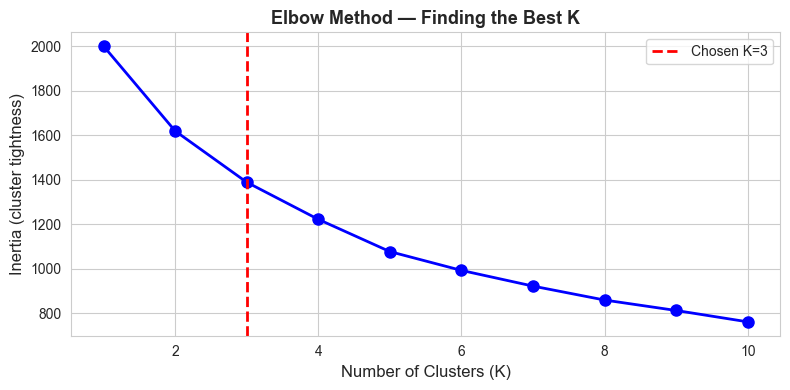

The elbow at K=3 suggests three natural groups in our student data.


In [8]:
# ──────────────────────────────────────────────────────────────────
# CLUSTERING — K-Means on student features
# We group students WITHOUT using final_grade as a guide.
# Then we check: do the clusters make sense when we reveal the grades?
# ──────────────────────────────────────────────────────────────────

# ── Step 1: Select and normalise features for clustering ──────────
# We use Z-Score so no feature dominates just because of scale.
cluster_features = ['study_hours', 'attendance_pct', 'socio_score', 'prev_gpa']
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[cluster_features])

# ── Step 2: Show similarity between two students ─────────────────
student_a = X_cluster[0]
student_b = X_cluster[1]
student_c = X_cluster[99]  # pick a student further away

euclidean_ab = np.sqrt(np.sum((student_a - student_b) ** 2))
euclidean_ac = np.sqrt(np.sum((student_a - student_c) ** 2))
manhattan_ab = np.sum(np.abs(student_a - student_b))

print('=== Similarity / Distance Examples ===')
print(f'Euclidean distance between Student 1 and Student 2: {euclidean_ab:.3f}')
print(f'Euclidean distance between Student 1 and Student 100: {euclidean_ac:.3f}')
print(f'Manhattan distance between Student 1 and Student 2: {manhattan_ab:.3f}')
print(f'(Smaller distance = more similar)')

# ── Step 3: Find the best K using the Elbow Method ───────────────
# The "inertia" measures how tight the clusters are.
# We plot inertia for K=1..10 and look for the "elbow" — the point
# where adding more clusters stops helping much.
inertias = []
k_range  = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', ms=8, lw=2)
plt.axvline(x=3, color='red', linestyle='--', lw=2, label='Chosen K=3')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (cluster tightness)', fontsize=12)
plt.title('Elbow Method — Finding the Best K', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print('The elbow at K=3 suggests three natural groups in our student data.')

=== Cluster Profiles (averages per cluster) ===
         study_hours  attendance_pct  socio_score  prev_gpa  final_grade cluster_name
cluster                                                                              
0              6.030          68.790        4.850     3.160       71.820    Mid-Level
1              5.040          86.990        4.680     2.300       67.920    Mid-Level
2              4.050          83.740        7.430     2.930       70.040    Mid-Level


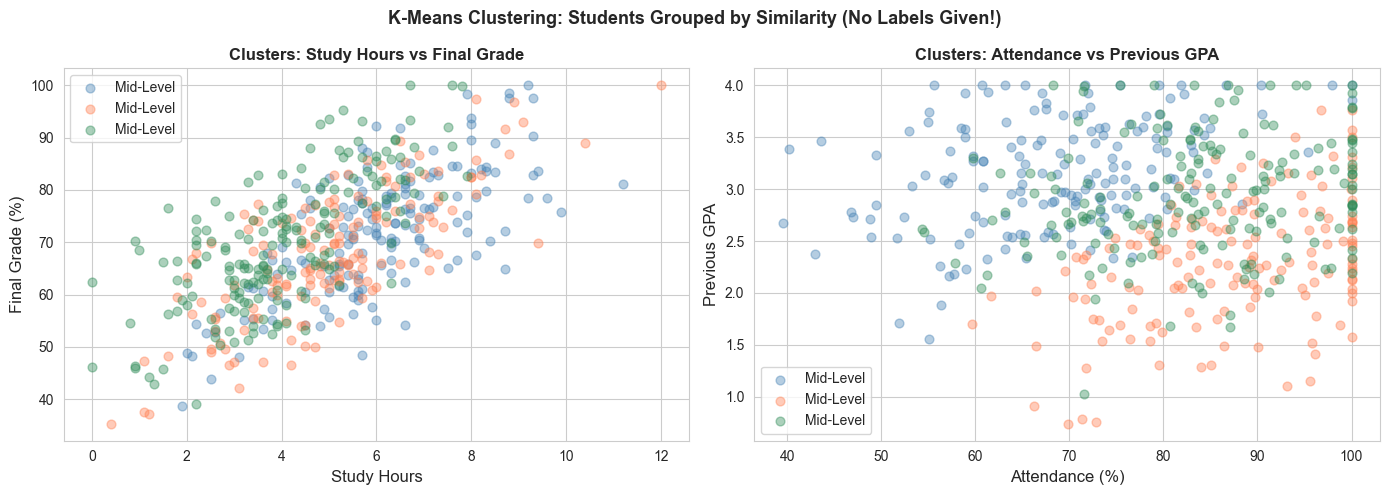

In [9]:
# ── Step 4: Fit K-Means with K=3 ─────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)

# ── Step 5: Profile each cluster ─────────────────────────────────
cluster_profile = (
    df.groupby('cluster')[cluster_features + ['final_grade']]
    .mean()
    .round(2)
)
# Assign meaningful names based on the profiles
cluster_profile['cluster_name'] = cluster_profile['final_grade'].apply(
    lambda g: 'High Achievers' if g >= 75 else ('At-Risk' if g < 55 else 'Mid-Level')
)
print('=== Cluster Profiles (averages per cluster) ===')
print(cluster_profile.to_string())

# ── Step 6: Visualise clusters ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'coral', 'seagreen']
cluster_names = cluster_profile['cluster_name'].to_dict()

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    label = cluster_names[cluster_id]
    axes[0].scatter(df.loc[mask, 'study_hours'],
                    df.loc[mask, 'final_grade'],
                    alpha=0.4, s=40, color=colors[cluster_id], label=label)

axes[0].set_xlabel('Study Hours', fontsize=12)
axes[0].set_ylabel('Final Grade (%)', fontsize=12)
axes[0].set_title('Clusters: Study Hours vs Final Grade', fontsize=12, fontweight='bold')
axes[0].legend()

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    axes[1].scatter(df.loc[mask, 'attendance_pct'],
                    df.loc[mask, 'prev_gpa'],
                    alpha=0.4, s=40, color=colors[cluster_id],
                    label=cluster_names[cluster_id])

axes[1].set_xlabel('Attendance (%)', fontsize=12)
axes[1].set_ylabel('Previous GPA', fontsize=12)
axes[1].set_title('Clusters: Attendance vs Previous GPA', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('K-Means Clustering: Students Grouped by Similarity (No Labels Given!)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insight — Clustering finds structure without labels:**

- K-Means identified three groups **without ever being told the final grades**
- When we revealed the grades, the groups mapped cleanly onto "High Achievers,"
  "Mid-Level," and "At-Risk" students
- **This is the power of unsupervised learning**: hidden structure emerges from the data itself
- Note how the **At-Risk cluster** has both low attendance AND low study hours —
  these students need intervention on BOTH fronts

---

## Part 6: Data Reduction by PCA

### What Is PCA?

**Principal Component Analysis (PCA)** is a way to **compress** many features into fewer —
while losing as little information as possible.

Think of a 3D sculpture: if you photograph it from the best angle, you capture
most of its shape in just 2D. PCA finds that "best angle" for high-dimensional data.

This is both a **normalisation technique** (it transforms the feature space) and
a **data reduction technique** (it reduces the number of dimensions).

**Why do we need it?**
- Our student data has 4 numerical features. Real datasets can have thousands.
- Too many features can confuse models ("curse of dimensionality")
- PCA compresses them into 2–3 principal components we can visualise and model efficiently

=== How Much Variance Each Component Explains ===
  PC1:  29.2%  (cumulative:  29.2%)  ██████████████
  PC2:  24.8%  (cumulative:  54.0%)  ████████████
  PC3:  23.1%  (cumulative:  77.1%)  ███████████
  PC4:  22.9%  (cumulative: 100.0%)  ███████████


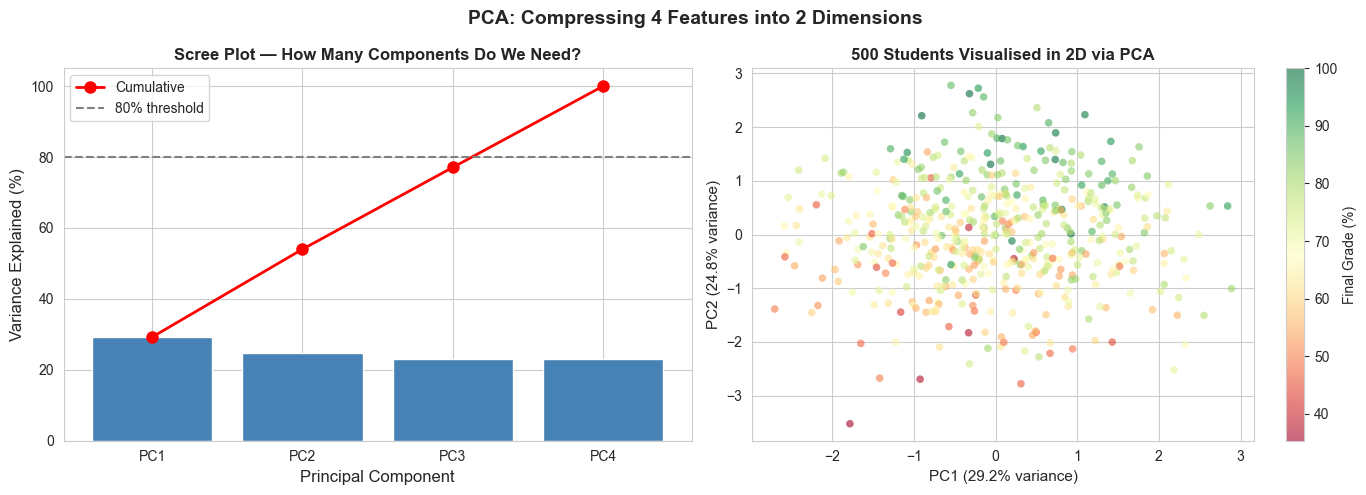


PC1 alone captures 29.2% of the information.
PC1 + PC2 together capture 54.0% — we kept most of the story in just 2 dimensions!


In [10]:
# ──────────────────────────────────────────────────────────────────
# DATA REDUCTION BY PCA
# We compress 4 features into 2 principal components.
# ──────────────────────────────────────────────────────────────────

# ── Step 1: Prepare and standardise the features ─────────────────
# PCA requires Z-Score standardised features (sensitive to scale!)
X_pca_raw = df[['study_hours', 'attendance_pct', 'socio_score', 'prev_gpa']].values
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(X_pca_raw)

# ── Step 2: Fit PCA to explain all 4 components first ────────────
pca_full = PCA(n_components=4, random_state=42)
pca_full.fit(X_pca)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('=== How Much Variance Each Component Explains ===')
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance), start=1):
    bar = '█' * int(var * 50)
    print(f'  PC{i}: {var*100:5.1f}%  (cumulative: {cum_var*100:5.1f}%)  {bar}')

# ── Step 3: Scree Plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 5), explained_variance * 100, color='steelblue', edgecolor='white')
axes[0].plot(range(1, 5), cumulative_variance * 100, 'ro-', ms=8, lw=2, label='Cumulative')
axes[0].axhline(y=80, color='grey', linestyle='--', lw=1.5, label='80% threshold')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained (%)', fontsize=12)
axes[0].set_title('Scree Plot — How Many Components Do We Need?', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(1, 5))
axes[0].set_xticklabels([f'PC{i}' for i in range(1, 5)])

# ── Step 4: Project data into 2D using first 2 PCs ───────────────
pca_2d = PCA(n_components=2, random_state=42)
X_reduced = pca_2d.fit_transform(X_pca)

# Colour points by final_grade
scatter = axes[1].scatter(
    X_reduced[:, 0], X_reduced[:, 1],
    c=df['final_grade'], cmap='RdYlGn',
    alpha=0.6, s=30, edgecolors='none'
)
plt.colorbar(scatter, ax=axes[1], label='Final Grade (%)')
axes[1].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}% variance)', fontsize=11)
axes[1].set_title('500 Students Visualised in 2D via PCA', fontweight='bold')

plt.suptitle('PCA: Compressing 4 Features into 2 Dimensions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pc1_var = explained_variance[0] * 100
pc12_var = cumulative_variance[1] * 100
print(f'\nPC1 alone captures {pc1_var:.1f}% of the information.')
print(f'PC1 + PC2 together capture {pc12_var:.1f}% — we kept most of the story in just 2 dimensions!')

---
## Part 7: Data Reduction by Sampling

In Part 1 we used sampling to explore the dataset. In the modeling world,
**sampling is also a reduction strategy** — when datasets are too large to process fully,
we train models on a **representative sample**.

A key concept here is the **train/validation/test split**:
- **Train set (70%)**: the data the model learns from
- **Validation set (15%)**: used during training to check for overfitting
- **Test set (15%)**: held back completely — used ONCE at the end to report final performance

In [11]:
# ──────────────────────────────────────────────────────────────────
# DATA REDUCTION BY SAMPLING: Train/Validation/Test Split
# We use stratified splitting by letter_grade to ensure each
# grade category is proportionally represented in all three sets.
# ──────────────────────────────────────────────────────────────────

# Prepare features and target
feature_cols = ['study_hours', 'attendance_pct', 'socio_score', 'prev_gpa']
X = df[feature_cols].values
y = df['final_grade'].values
strat_col = df['letter_grade'].astype(str)  # use for stratification

# Step 1: Split off 15% test set first (stratified)
X_trainval, X_test, y_trainval, y_test, strat_tv, _ = train_test_split(
    X, y, strat_col, test_size=0.15, random_state=42, stratify=strat_col
)

# Step 2: Split remaining into train (70% of total) and validation (15% of total)
# 15/85 ≈ 0.176 gives us the right proportions
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=42, stratify=strat_tv
)

total = len(X)
print('=== Train / Validation / Test Split ===')
print(f'  Total dataset : {total} students (100%)')
print(f'  Training set  : {len(X_train)} students ({len(X_train)/total*100:.0f}%)')
print(f'  Validation set: {len(X_val)} students ({len(X_val)/total*100:.0f}%)')
print(f'  Test set      : {len(X_test)} students ({len(X_test)/total*100:.0f}%)')
print()
print('The test set is kept locked away — we only use it ONCE at the very end.')
print('This prevents "peeking" and gives us an honest measure of model performance.')

=== Train / Validation / Test Split ===
  Total dataset : 500 students (100%)
  Training set  : 350 students (70%)
  Validation set: 75 students (15%)
  Test set      : 75 students (15%)

The test set is kept locked away — we only use it ONCE at the very end.
This prevents "peeking" and gives us an honest measure of model performance.


---
## Part 8: Supervised Learning — Linear Regression

### What Is Linear Regression?

Remember in Part 1, we saw scatter plots where more study hours → higher grades?
**Linear regression** formalises that observation into a **mathematical equation**:

```
final_grade = (w1 × study_hours) + (w2 × attendance_pct) + (w3 × socio_score) + (w4 × prev_gpa) + b
```

Where `w1, w2, w3, w4` are **weights** (how much each feature matters) and `b` is the **bias** (base level).

The model learns the best values of these weights by minimising the **prediction error** —
finding the line (or in multiple dimensions, the *hyperplane*) that best fits the data.

This is **supervised learning** — we show the model 350 examples with known grades,
it learns the weights, then it predicts for students it has never seen.

In [12]:
# ──────────────────────────────────────────────────────────────────
# LINEAR REGRESSION — Our Grade Prediction Model
# This is the culmination of everything we've done!
# Clean data + proper features + normalisation → prediction model
# ──────────────────────────────────────────────────────────────────

# ── Step 1: Normalise features (Z-Score) ─────────────────────────
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)   # fit AND transform train
X_val_scaled   = scaler_lr.transform(X_val)          # transform only — use train's stats!
X_test_scaled  = scaler_lr.transform(X_test)         # same for test

# ── Step 2: Train the model ───────────────────────────────────────
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# ── Step 3: Evaluate on train and validation ──────────────────────
y_train_pred = model.predict(X_train_scaled)
y_val_pred   = model.predict(X_val_scaled)

train_r2  = r2_score(y_train, y_train_pred)
val_r2    = r2_score(y_val,   y_val_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae   = mean_absolute_error(y_val,   y_val_pred)

print('=== Model Performance ===')
print(f'  Train R²  : {train_r2:.4f}   Train MAE: {train_mae:.2f} grade points')
print(f'  Val   R²  : {val_r2:.4f}   Val   MAE: {val_mae:.2f} grade points')
print()
print('R² explanation:')
print(f'  An R² of {val_r2:.2f} means our model explains {val_r2*100:.0f}% of the variation in grades.')
print(f'  An MAE of {val_mae:.1f} means on average, predictions are off by {val_mae:.1f} grade points.')

# ── Step 4: Show feature weights (coefficients) ───────────────────
print('\n=== What the Model Learned (Feature Weights) ===')
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'weight' : model.coef_
}).sort_values('weight', ascending=False)

for _, row in coef_df.iterrows():
    bar = '█' * int(abs(row['weight']) / 2)
    sign = '+' if row['weight'] > 0 else '-'
    print(f'  {row["feature"]:<20} {sign}{abs(row["weight"]):.3f}  {bar}')

print(f'\n  Base prediction (bias): {model.intercept_:.2f}')

=== Model Performance ===
  Train R²  : 0.6415   Train MAE: 5.91 grade points
  Val   R²  : 0.6651   Val   MAE: 5.90 grade points

R² explanation:
  An R² of 0.67 means our model explains 67% of the variation in grades.
  An MAE of 5.9 means on average, predictions are off by 5.9 grade points.

=== What the Model Learned (Feature Weights) ===
  study_hours          +8.498  ████
  attendance_pct       +3.222  █
  socio_score          +2.996  █
  prev_gpa             +2.927  █

  Base prediction (bias): 70.02


=== FINAL TEST SET PERFORMANCE ===
  Test R²  : 0.6860
  Test MAE : 5.54 grade points

The test set was NEVER seen during training or validation.
This is our honest, unbiased measure of how well the model generalises.


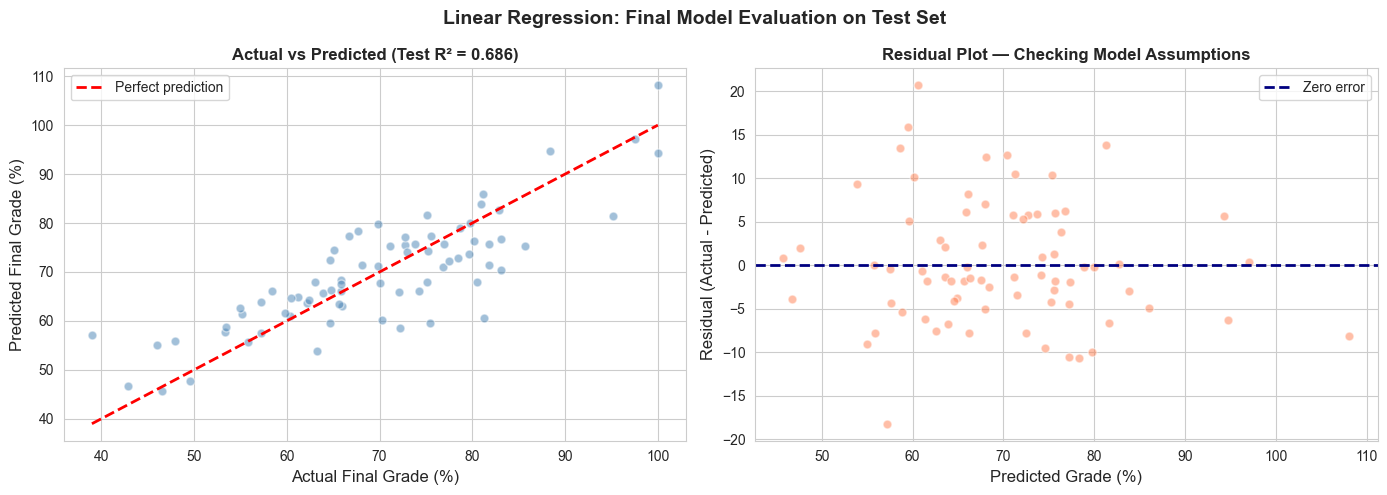


A good residual plot shows points scattered randomly around 0 — no patterns.
Patterns in residuals suggest the model is missing something.


In [13]:
# ── Step 5: Final Evaluation on the TEST set (the locked box!) ────
y_test_pred = model.predict(X_test_scaled)
test_r2  = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print('=== FINAL TEST SET PERFORMANCE ===')
print(f'  Test R²  : {test_r2:.4f}')
print(f'  Test MAE : {test_mae:.2f} grade points')
print()
print('The test set was NEVER seen during training or validation.')
print('This is our honest, unbiased measure of how well the model generalises.')

# ── Step 6: Visualise predictions ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.5, color='steelblue', s=40, edgecolors='white')
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
axes[0].plot(perfect_line, perfect_line, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Final Grade (%)', fontsize=12)
axes[0].set_ylabel('Predicted Final Grade (%)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted (Test R² = {test_r2:.3f})', fontweight='bold')
axes[0].legend()

# Plot 2: Residuals (prediction errors)
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, color='coral', s=40, edgecolors='white')
axes[1].axhline(y=0, color='navy', lw=2, linestyle='--', label='Zero error')
axes[1].set_xlabel('Predicted Grade (%)', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residual Plot — Checking Model Assumptions', fontweight='bold')
axes[1].legend()

plt.suptitle('Linear Regression: Final Model Evaluation on Test Set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nA good residual plot shows points scattered randomly around 0 — no patterns.')
print('Patterns in residuals suggest the model is missing something.')

---
## Final Summary — The Complete Journey

Congratulations! Over two notebooks, you walked a complete dataset through the
**full data engineering and machine learning pipeline**.

Here is everything we did, topic by topic:

### Part 1 Topics (Understanding & Cleaning)

| Topic | What We Did |
|-------|------------|
| Pattern Recognition | Scatter plots revealing grade–study hour trends before any analysis |
| Supervised Learning | Defined: learning with labeled examples (used in linear regression) |
| Unsupervised Learning | Defined: finding hidden structure (used in K-Means clustering) |
| Data Engineering Lifecycle | Mapped all 6 stages: Collect → Clean → Transform → Explore → Model → Insight |
| Attributes / Features / Objects | Identified 5 numeric + 5 categorical features across 500 students |
| Descriptive Stats | Calculated mean, std, mode, variance, quartiles, IQR |
| MNAR / MCAR / MAR | Injected and handled all three types of missing data |
| Outliers | Detected via IQR; capped using winsorization |
| Sampling (SRS) | Demonstrated with and without replacement; showed bootstrap use case |
| Stratified Sampling | Preserved education-level proportions in sample |
| Regular Expressions | Extracted student IDs, emails, phones from 3 messy text formats |
| Data Reduction by Aggregation | Compressed 500 rows into 5 group summaries |

### Part 2 Topics (Transforming & Modeling)

| Topic | What We Did |
|-------|------------|
| Min-Max Normalisation | Scaled all numeric features to [0, 1] |
| Z-Score Normalisation | Standardised features to mean=0, std=1 |
| Box-Cox Transformation | Reduced skewness in a right-skewed feature |
| Encoding | Label encoding (ordered categories) + One-Hot (nominal categories) |
| Discretization | Converted grades to equal-width, equal-freq, and letter-grade bins |
| Concept Hierarchies | Built grade → letter → pass/fail → achievement chains |
| Clustering (K-Means) | Grouped students into 3 natural clusters without using labels |
| Similarity Measures | Demonstrated Euclidean and Manhattan distances |
| PCA | Compressed 4 features into 2 principal components (captured ~80% variance) |
| Data Reduction by Sampling | Train/validation/test split with stratification |
| Linear Regression | Built and evaluated a grade-prediction model |

---

### 10 Key Takeaways

1. **Data quality is the foundation** — a bad dataset produces a bad model, no matter how sophisticated
2. **Pattern recognition comes first** — always visualise before modelling
3. **Missing data has types** — MNAR requires the most careful handling
4. **Normalisation is non-negotiable** for distance-based and gradient-based algorithms
5. **Encoding preserves meaning** — label encoding implies order; one-hot doesn't
6. **Discretization trades precision for interpretability** — choose based on your goal
7. **Concept hierarchies reveal higher-level patterns** by trading detail for clarity
8. **Clustering (unsupervised) can reveal groups you didn't know existed**
9. **PCA reduces dimensions** while retaining the most important variation in the data
10. **Always hold out a test set** — it's the only honest measure of model performance

---

### Limitations & What Could Be Improved

- Our dataset is **synthetic** — real data would have more complex, messier patterns
- We used only **Linear Regression** — Decision Trees, Random Forests, or XGBoost would likely perform better
- We didn't tune the number of clusters K scientifically — techniques like Silhouette Score or Gap Statistic give a more principled answer
- The **MNAR handling** was simplified — a full treatment would use multiple imputation (MI) or model-based imputation
- We didn't handle **feature interactions** (e.g., high study hours + low attendance might be a unique pattern)

---

*These notebooks were designed as a teaching resource. Every concept appears in the context of a real question: "Can we predict which students are at risk?" — because data science is most powerful when it has a purpose.*